# Competitor Analysis Using Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System

## Business Context
Performing competitor analysis with a Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System.

## Problem Scenario
Conducting a robust competitor analysis of a company is a time-consuming and research-intensive process that may be prone to errors for example, outdated information.

Analysts spend significant time gathering data, identifying relevant competitors, and synthesizing insights into actionable recommendations.

## Objective
To address above mentioned challenges, a Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System is proposed.

This system will perform competitor analysis of a given company by comparing it with its key rivals in the relevant industry using the latest available web data.

Users will input a company name (e.g., "Tesla") and receive a well-structured report, comparing that company to its primary competitors (e.g., in the electric vehicle sector for Tesla), by leveraging a multi-agent collaborative architecture powered by RAG capabilities.

The system should deliver rapid, accurate, and actionable insights.

## Solution Approach

A Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System is implemented using a sequential workflow pattern.

This system automates competitor analysis by breaking down the task into distinct steps handled by specialized agents.

The sequential pattern ensures each step builds on the previous one. Also, incorporating RAG to retrieve and augment data from a vector database for context-aware insights.


**Below are the key components of the implementation:**

### State Management

The workflow uses a Pydantic-based state `CompetitiveAnalysisState` to track variables like company name, generated questions, search results, vectorstore status, and the final report.

### Tools
- `suggest_questions`: Generates relevant questions for competitor analysis using the LLM.
- `fetch_search_results`: Searches the web via Tavily API to fetch answers for the questions.
- `store_in_chromadb`: Stores question-answer pairs in ChromaDB for efficient retrieval.
- `generate_report`: Uses RAG to query the vectorstore and draft a structured report.




### Agents

- `Question Generator Agent`: Validates the company, identifies its sector, and generates analysis questions.

- `Data Retrieval and Storage Agent`: Fetches answers from the web and stores them in the vector database.

- `Report Drafter Agent`: Retrieves stored data via RAG and generates a professional, actionable report with sections like Executive Summary, Company Overview, Key Competitors, Strengths/Weaknesses, Market Strategies, and Recommendations.




### Workflow (Sequential Pattern)

The system uses LangGraph's StateGraph to define nodes for each agent.
Edges connect the nodes sequentially as indicated below.

`START → Question Generation → Data Retrieval/Storage → Report Drafting → END.`

The final output is formatted competitive analysis report, displayed in Markdown for readability.

# Installing the Libraries

Installing the libraries:
- **openai==1.99.9** → Official OpenAI client library for interacting with GPT models.  
- **langchain==0.3.27** → Core framework for building applications powered by LLMs.  
- **langchain-openai==0.3.30** → LangChain integration for OpenAI models.  
- **langchain-community==0.3.27** → Community-contributed LangChain modules (tools, integrations).  
- **langgraph==0.6.4** → Build and manage multi-step workflows or agent graphs for LLM-powered systems.  
- **langchain-chroma==0.2.5** → Connector for using **ChromaDB** as a vector database with LangChain.  
- **chromadb==1.0.16** → Open-source vector database for storing and retrieving embeddings.  
- **langchain-tavily==0.2.11** → Integration for the **Tavily API** (specialized web search + retrieval for RAG).  

In [57]:
#Install required packages
!pip install -q openai==1.99.9 \
                langchain==0.3.27 \
                langchain-openai==0.3.30 \
                langchain-community==0.3.27 \
                langgraph==0.6.4 \
                langchain-chroma==0.2.5 \
                chromadb==1.0.16 \
                langchain-tavily==0.2.11

# Setting up the Environment

## **Importing the relevant packages**

In [58]:
import os
import json
import random
import datetime

from typing import TypedDict, List, Optional, Dict, Tuple, Any

from pydantic import BaseModel, Field,ConfigDict

import chromadb

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import StructuredTool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.retrievers import BaseRetriever
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent
from langchain_tavily import TavilySearch

from IPython.display import Image, display, Markdown

from google.colab import userdata

import time
import uuid
from langchain_core.documents import Document

import warnings
warnings.filterwarnings('ignore')

## **Instantiating the required variables**

Set the environment variables.

To securely connect with external APIs (like OpenAI and Tavily), we’ll set up our **environment variables**.  
This ensures our API keys are not hard-coded directly in the notebook, keeping them safe.

- **OPENAI_API_KEY**
- **OPENAI_BASE_URL**
- **TAVILY_API_KEY**

After running this cell, your notebook will be able to access both **OpenAI** and **Tavily APIs** securely.


In [59]:
# Set environment variables
openai_api_key = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = openai_api_key
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
os.environ['OPENAI_BASE_URL'] = "https://aibe.mygreatlearning.com/openai/v1"

Now that our environment variables are set, let's initialize the **core models** we'll use in this project:

Initialize the Chat Model:

Use ChatOpenAI to create a model instance named llm. You must explicitly set the model to 'gpt-4o-mini', the temperature to 0 (for consistency), and provide the api_key and base_url derived from your environment variables.

In [60]:
# A temperature of 0 is vital for multi-agent systems to prevent creative but incorrect branching.
llm = ChatOpenAI(
    api_key = openai_api_key,
    base_url ="https://aibe.mygreatlearning.com/openai/v1",
    model= 'gpt-4o-mini',
    temperature = 0
)

Initialize the Embedding Model: Create an instance named embedding_model using OpenAIEmbeddings. This model will be responsible for converting your research data into vector representations. Use the 'text-embedding-3-small' model and ensure it points to the correct base_url.

In [61]:
# Ensure the base_url matches the one used for the LLM.
embedding_model = OpenAIEmbeddings(
    api_key = openai_api_key,
    base_url = "https://aibe.mygreatlearning.com/openai/v1",
    model = 'text-embedding-3-small'
)

To enable **Retrieval-Augmented Generation (RAG)**, we need a place to store and query text embeddings.  
Here, we'll use **ChromaDB**, an open-source vector database.

Setting up the Chroma vector database client and a Chroma vector store collection for storing and retrieving search results.

In [62]:
# ChromaDB set up Persistent client
chromadb_client = chromadb.PersistentClient(
    path = './chroma'
)

# Set up vectorstore
vector_store = Chroma(
    collection_name = 'question_collection',
    collection_metadata = {'hnsw:space': 'cosine'},
    embedding_function = embedding_model,
    client = chromadb_client,
    persist_directory = './chroma'
)


In [63]:
chromadb_client.count_collections()

1

# **State Definitions **

Lets define the Pydantic models for structured outputs - 'QuestionSuggestion' and the overall state - 'CompetitiveAnalysisState'  .
State Definition ensure type safety and structure the data passed between agents and nodes.

## **QuestionSuggestion **


This model will help ensure that the responses from the LLM follow a **consistent format**, making them easier to validate and use later.

- Create a class that inherits from `BaseModel`.  
- Fields include:
  - **sector** → The industry sector of the company.  
  - **is_valid_company** →  A boolean flag for whether the company name is recognized.  
  - **questions** → A list of suggested competitive analysis questions.  
  - **error_message** → Optional field to capture any errors that occur.  

- The `Field()` argument ensures that **default values** and **descriptions** are available for each attribute.  


### Define the `QuestionSuggestion` State Model

In this step, you will define a **Pydantic model** to standardize the structured
output returned by the LLM when generating competitive analysis questions.

You need to perform the following steps:

- Create a class named `QuestionSuggestion` that inherits from `BaseModel`.
- Define a field to store the **industry sector** of the company.
- Define a **boolean field** to indicate whether the company name is valid or recognized.
- Define a field to store a **list of competitive analysis questions**.
- Define an **optional field** to capture error messages, if any occur.
- Use `Field()` to:
  - Specify default values where appropriate.
  - Add meaningful descriptions for each field.
- Ensure the model supports structured validation for downstream processing.

Write your code in the below cell.


In [64]:
# Define the QuestionSuggestion Pydantic model
class QuestionSuggestion(BaseModel):
  """
  The structured output for the competitive analysis
  """
  sector: str = Field(None, description= 'The industry sector of the company.')
  is_valid_company: bool = Field(default = False, description='A boolean flag for whether the company name is recognized/ exists, if not returns Unkown')
  questions: List[str] = Field(default=[], desctiption = 'a list of the actual reasearch questions to be answered')
  error_message: str = Field(None, description='Optional field to capture any errors that occur')




## **Competitive Analysis State **

Next, we’ll create a state object for keeping track off the competitive analysis that keeps track of all the information our pipeline generates and updates during the competitive analysis workflow.

This will act as a “shared memory” object, making it easier to pass data between steps in the system.

- Fields include:
  - **company_name** → The company being analyzed.  
  - **max_num_of_questions** → The maximum number of questions to generate (use a constant as the default).  
  - **sector** → The industry sector (optional).  
  - **is_valid_company** → Boolean flag to mark if the company is recognized (optional).  
  - **question_list** → List of generated analysis questions (optional).  
  - **qna_results** → Stores answers to questions as a list of dictionaries (optional).  
  - **vectorstore** → Chroma vector database instance for retrieval.  
  - **chromadb_insert_status** → Tracks whether data was successfully stored in Chroma (optional).  
  - **report** → Final competitive analysis report (optional).  
  - **error_message** → Captures any error details (optional).

- The `model_config` setting allows **non-Pydantic types** (e.g., Chroma objects).


This state acts as a central memory structure that stores intermediate and
final outputs generated during execution.

Follow the steps below:

- Define a constant to represent the **maximum number of questions** allowed.
- Create a class named `CompetitiveAnalysisState` that inherits from `BaseModel`.
- Define a required field to store the **company name** being analyzed.
- Define a field for the **maximum number of questions**, using the constant as the default value.
- Define optional fields to store:
  - Industry sector
  - Company validity flag
  - Generated question list
  - Question–answer results
  - ChromaDB insertion status
  - Final report
  - Error messages
- Include a field to store the **Chroma vector store instance** used for retrieval.
- Configure the model to allow **non-Pydantic types** using `model_config`.

Write your code in the below cell.

In [65]:
#Setting maximum limit to number of genetated questions
MAX_NUM_OF_QUESTIONS = 40

In [66]:
class CompetitiveAnalysisState(BaseModel):

  company_name: str = Field(None, description= 'The company being analyzed')
  max_num_of_questions: int = Field(default = MAX_NUM_OF_QUESTIONS, description='The maximum number of questions to generate')
  sector: Optional[str] = Field(None, description='The industry sector')

  is_valid_company: Optional[bool] = Field(default = False, description='Boolean flag to mark if the company is recognized ')

  question_list: Optional[List[str]] = Field(None, description='List of generated analysis questions ')

  qna_results: Optional[List[Dict[str, Any]]] = Field(
        default=None,
        description="List of question-answer pairs generated during analysis"
    )
  vectorstore: Optional[Any] = Field(default = None, description='Chroma vector database instance for retrieval')
  chromadb_insert_status: Optional[bool] = Field(default = False, description='Tracks whether data was successfully stored in Chroma')
  report: Optional[str] = Field(default= None, description = 'Final competitive analysis report')
  error_message: Optional[str] = Field(default = None, description='Captures any error details ')

# **Tools **

## **Tavily Search Tool**

Initialize the Tavily Search tool to retrieve external company-related
information that will later be embedded into the vector store and used
for retrieval-augmented generation (RAG).

The search tool should be configured to:
- Limit the number of returned search results.
- Optionally include a synthesized answer from Tavily.
- Optionally include raw page content for richer context.
- Use an advanced search depth for more comprehensive results.

This tool will be reused by downstream agents for fetching competitive
analysis information.

Write your code in the below cell.


In [67]:
# Initialize the TavilySearch tool here
tavily_search = TavilySearch(max_results = 1,
                             search_depth = 'advanced',
                             include_raw_content = True,
                             include_images = False,
                             include_answer=True)

Below section defines the tools used by the agents for,
- Suggesting questions,
- Fetching search results,
- Storing data in ChromaDB, and
- Generating the report.

## **Suggest Questions Tool**

Create a custom LangChain tool named `suggest_questions` to generate structured
competitive analysis questions for a given company.

- Define a LangChain tool function that accepts a company name and a maximum
  number of questions as inputs.
- Build an LLM prompt that:
  - Verifies whether the company is real or recognized.
  - Identifies the industry sector of the company.
  - Generates targeted competitor analysis questions covering competitors,
    pricing, technology, supply chain, strengths, weaknesses, and market
    opportunities.
- Invoke the LLM using structured output enforcement with the
  `QuestionSuggestion` schema.
- Extract the sector, company validity flag, and generated questions from the
  structured response.
- Return the extracted data as a JSON-formatted string.
- Handle runtime or model errors by returning default values and an error message.

This tool will be used by downstream agents in the competitive analysis workflow.

Write your code in the below cell.


In [68]:
# Register this function as a LangChain tool
@tool
def suggest_questions(company_name: str, max_num_of_questions: int) -> str:
  """
  Take the company name {company_name} and the maximum number os questions {max_num_of_questions} as an inpute
  generate competitive analysis questions


  """

  sytem_message = """
  You are a powerful competitive analysis questions generator.
  take the company name {company_name}, check if the company is real/recognized
  if the company name is not not recognized return is_valid_company False
  if the company exists identify the industry / sector  it operates in
  then generate targeted competitive analysis questions covering competitors, pricing, technology, supply chain, strengths, weaknesses, and market opportunities.
  store the generated questions and store them in the list called questions

  Constraints:
  Do not generate more than {max_num_of_questions} number of questions

  """

  #check is the company name exists
  #we will verify the company name in two laters: 1st throught tavily search and then through the LLM
  print("--VALIDATING COMPANY NAME FROM WEBSEARCH--")
  search_company_name = tavily_search.invoke(input= company_name+' '+'company')
  if company_name in search_company_name['results'][0]['title']:
    #state.is_valid_company == True

    print(f'Name: {company_name} is a valid company! \n')
  else:
    #state.is_valid_company == False
    print(f'Name: {company_name} is not a valid company! \n')

  try:
      prompt = ChatPromptTemplate.from_messages([
          ('system', sytem_message),
          ('user', f'company: {company_name}. Generate up to {max_num_of_questions} questions')
      ])

      chain = prompt | llm.with_structured_output(QuestionSuggestion)
      result = chain.invoke({
          'company_name': company_name,
          'max_num_of_questions': max_num_of_questions
      })


      print("--VALIDATING COMPANY NAME FROM LLM--")
      is_valid_company = result.is_valid_company
      print(f'Is {company_name} a valid company? {is_valid_company} \n')

      print(f'---RETRIEVING {company_name.upper()} INDUSTRY--')
      sector = result.sector
      print(f'Sector: {sector} \n')

      print('----GETTING LIST OF QUESTIONS--')
      questions = result.questions
      n = 1
      for question in questions :
        print(f'Question {n}: {question}')
        n+=1

      print(f'\n--COMPETITIVE ANALYSIS QUESTIONS GENERATED SUCCESSFULLY FOR {company_name.upper()}-- \n')

      output = {
          'sector': sector,
          'is_valid_company': is_valid_company,
          'questions': questions,
          'error_message': result.error_message

      }


  except Exception as e:
      print(f'An error as occurred: {str(e)}')

      output = {
          'sector': '',
          'is_valid_company': False,
          'questions': [],
          'error_message': str(e)

      }


  return json.dumps(output)



## **Fetch Search Result Tool **

The Fetch Search Result tool will take each question, query the **Tavily Search API**, and collect the results.

The function **iterates** through the `question_list` and for each question:
     - Call `search.invoke({"query": question})` to get Tavily search results.  
     - Check if the result contains an `"answer"`.  
     - Store the pair (`question`, `answer`) in a list of dictionaries.  
Additionally, the function can:
- **Handle missing answers** by storing an empty string.
- Handle errors** with a `try/except` block and log them for debugging.  
- Return the **final results as a JSON string**.

Create a custom LangChain tool named `fetch_search_results` to retrieve answers
for generated competitive analysis questions using the Tavily Search API.

In this cell, implement logic to:
- Define a LangChain tool function that accepts a list of questions as input.
- Iterate over each question in the provided list.
- Query the Tavily Search API for each question.
- Check whether the search response contains a valid answer.
- Store each question and its corresponding answer as a dictionary.
- Handle missing or empty answers by storing an empty string.
- Catch and log errors encountered during search execution.
- Return the complete list of question–answer pairs as a JSON-formatted string.

This tool will be used by downstream nodes to enrich the pipeline with
external search-based information.

Write your code in the below cell.


In [69]:
# Register this function as a LangChain tool
@tool
def fetch_search_results(question_list: List[str]) -> str:
  """

  """
  #list of questions
  #question_list = json.loads(questions)['questions']
    #create
  names = ['Question', 'Answer']
  QnA_list = []

  for question in question_list:

    try:
        search_answer = tavily_search.invoke({"query": question})

        answer = search_answer.get('aswer') if search_answer.get('aswer') is not None else " "

        QnA_dict = {names[0]:search_answer['query'],names[1]: search_answer['answer']}
        QnA_list.append(QnA_dict)

    except Exception as e:
      print(f'Error:{str(e)}')
      QnA_dict = {names[0]:search_answer['query'],names[1]: ''}
      QnA_list.append(QnA_dict)

    result = json.dumps(QnA_list)

  return result



## **Store in ChromaDB Tool**

After fetching question-answer pairs, they must be stored in **ChromaDB** so they can later be retrieved during the analysis.  
This tool will embed the answers and insert them into the vector store along with metadata for traceability.

The function `store_in_chromadb`:
- Loop through each question–answer dictionary.  
- **Skip empty answers** (don’t embed/store them).  
- For valid answers:  
    - Create a `documents` list containing the answer text.  
    - Create `metadatas` with fields such as:  
        - `question` → the original question  
        - `source_type` → `"answer"`  
        - `search_success` → whether a valid answer was found  
    - Create unique `ids` for each entry (e.g., `"doc_1"`, `"doc_2"`).  
- Use `vectorstore.add_texts()` to insert documents, metadata, and IDs into ChromaDB.  

Create a custom LangChain tool named `store_in_chromadb` to persist question–answer
data into a ChromaDB vector store for later retrieval.

In this cell, implement logic to:
- Define a LangChain tool function that accepts a list of question–answer
  dictionaries as input.
- Iterate through the list of question–answer entries.
- Skip entries where the answer is empty or missing.
- For each valid answer:
  - Prepare a list of documents containing the answer text.
  - Attach metadata that includes the original question, the source type, and
    whether the search was successful.
  - Generate unique document IDs for insertion into the vector store.
- Insert documents, metadata, and IDs into ChromaDB using the vector store API.
- Track whether all valid answers were successfully stored.
- Return the final insertion status as a JSON-formatted string.

This tool enables retrieval-augmented generation in later stages of the workflow.

Write your code in the below cell.


In [70]:
# Register this function as a LangChain tool
@tool
def store_in_chromadb(qna_results: List[Dict]) -> str:
    """
    Store question-answer pairs into ChromaDB vector store for later retrieval.
    Skips empty answers and tracks insertion status.

    Args:
        qna_results: A list of question-answer dictionaries with 'Question' and 'Answer' keys.

    Returns:
        A JSON-formatted string indicating the insertion status and document count.
    """
    #qna_results =json.loads(fetch_search_results(question_list))
    start_time = time.time()
    print("CREATING DOCUMENTS WITH METADATA...")

    documents = []
    metadatas = []
    ids = []
    doc_counter = 1

    for qna in qna_results:
        answer = qna.get("Answer", "").strip()
        question = qna.get("Question", "")

        if not answer:
            print(f"[SKIP] No answer for question: '{question}'")
            continue

        documents.append(answer)
        metadatas.append({
            "question": question,
            "source_type": "answer",
            "search_success": True
        })
        ids.append(f"doc_{doc_counter}")
        doc_counter += 1

    if not documents:
        return json.dumps({
            "chromadb_insert_status": False,
            "inserted_count": 0,
            "error_message": "No valid answers to store."
        })

    print("CACHING DOCUMENTS INTO CHROMADB...")
    insert_status = False

    try:
        for i in range(0, len(documents), MAX_NUM_OF_QUESTIONS):
            batch_docs = documents[i:i + MAX_NUM_OF_QUESTIONS]
            batch_meta = metadatas[i:i + MAX_NUM_OF_QUESTIONS]
            batch_ids  = ids[i:i + MAX_NUM_OF_QUESTIONS]

            vector_store.add_texts(
                texts=batch_docs,
                metadatas=batch_meta,
                ids=batch_ids
            )
            time.sleep(1)

        insert_status = True
        end_time = time.time()
        print(f"Successfully inserted {len(documents)} documents into ChromaDB.")
        print(f"Execution time: {end_time - start_time:.2f}s")

    except Exception as e:
        print(f"[ERROR] ChromaDB insertion failed: {str(e)}")
        return json.dumps({
            "chromadb_insert_status": False,
            "inserted_count": 0,
            "error_message": str(e)
        })

    return json.dumps({
        "chromadb_insert_status": insert_status,
        "inserted_count": len(documents),
        "error_message": None
    })

## **Generate Report Tool**

The `generate_report` tool will be used to define precisely how to use retrieved context for generating the report by
- using the retrieved context as the primary source and comparing competitors across dimensions (market share, products, pricing, tech, supply chain, customer sentiment).
- highlighting differentiators and actionable strategies.
- structuring the final output into the named sections and citing context where relevant.

The functions builds a `human` message that requests a report for the given `company_name` and `sector` and includes a `{context}` placeholder which will be filled at runtime with retrieved documents from the vectorstore and combine messages into a `ChatPromptTemplate.from_messages([...])`

Create a custom LangChain tool named `generate_report` to define how retrieved
context is used to generate the final competitive analysis report.

In this cell, implement logic to:
- Define a LangChain tool function that accepts the company name and industry
  sector as inputs.
- Construct a system message that instructs the LLM to perform competitor
  analysis using retrieved context as the primary source of information.
- Ensure the analysis compares competitors across dimensions such as market
  share, products, pricing, technology, supply chain, and customer sentiment.
- Include instructions to highlight differentiators and propose actionable
  strategies.
- Build a human message that requests report generation for the given company
  and sector and includes a `{context}` placeholder.
- Combine system and human messages into a `ChatPromptTemplate`.
- Return the prompt template for downstream invocation (do not execute the LLM
  in this tool).

This tool defines the report structure and is used later within a RAG workflow.

Write your code in the below cell.


In [71]:
# Register this function as a LangChain tool
@tool
def generate_report(company_name: str, sector: str) -> str:
  """
  Define how to use retrieved context for generating the report
  use the retrieved context as the primary source and comparing competitors across dimensions
  highlight differentiators and actionable strategies.
  structure the final output into the named sections and citing context where relevant

  Args:
        company_name: The name of the company being analyzed.
        sector: The industry or sector the company operates in.

  Returns:
        A ChatPromptTemplate ready for downstream RAG invocation.


  """

  system_message = """
    You are an expert competitive intelligence analyst specializing in the {sector} industry.
    Using ONLY the retrieved context provided, generate a comprehensive competitive analysis report.

    Your analysis must compare competitors across the following dimensions:
    - Market Share        : Relative positioning and growth trends
    - Products & Services : Key offerings, differentiators, and portfolio breadth
    - Pricing Strategies  : Pricing models, tiers, and value propositions
    - Technology          : Innovation, R&D investment, and tech stack advantages
    - Supply Chain        : Operational efficiency, sourcing, and logistics strengths
    - Customer Sentiment  : Brand perception, reviews, loyalty, and satisfaction

    Additionally, your report must:
    - Highlight key differentiators that set {company_name} apart from competitors
    - Identify potential threats and vulnerabilities
    - Propose clear, actionable strategies for {company_name} to strengthen its market position

    Structure your report using the following sections:
    1. Executive Summary
    2. Industry Overview
    3. Competitor Landscape
    4. Dimension-by-Dimension Comparison
    5. Key Differentiators
    6. Threats & Vulnerabilities
    7. Actionable Recommendations
    8. Conclusion

    Cite the retrieved context where relevant to support your findings.
    If the context does not contain sufficient information for a section, state that explicitly.
    """

  human_message = """
    Generate a full competitive analysis report for **{company_name}** operating in the **{sector}** sector.

    Use the following retrieved context as your primary source of information:

    {context}

    Ensure the report is structured, evidence-based, and concludes with actionable strategies.
    """

  prompt = ChatPromptTemplate.from_messages([
      ("system", system_message),
      ('human', human_message)
  ])

  return prompt



# **Agents**

## **Initialize the Agents **

Below section creates reactive agents using LangChain's create_react_agent. Each agent is assigned specific tools:
- question_generator_agent: Uses suggest_questions tool.
- data_retrieval_storage_agent: Uses fetch_search_results and store_in_chromadb tool.
- report_drafter_agent: Uses generate_report tool.

### Questions Generator Agent

In [72]:
question_generator_agent = create_react_agent(
    model =llm,
    tools = [suggest_questions],
    prompt = SystemMessage(content = """
    You are a competitive analysis question generator.
    Use the suggest_questions tool to generate targeted competitive analysis questions
    for the given company. Return the structured output as provided by the tool.


    """)
)

### Data Retrieval & Storage Agent

In [73]:
data_retrieval_storage_agent = create_react_agent(
    model=llm,
    tools=[fetch_search_results, store_in_chromadb],
    prompt=(
        "You are a data retrieval and storage agent. "
        "First, use the fetch_search_results tool to retrieve answers for the provided questions. "
        "Then, use the store_in_chromadb tool to persist the question-answer pairs into the vector store. "
        "Return the storage status when complete."
    )
)


### Report Drafter Agent

In [74]:
report_drafter_agent = create_react_agent(
    model=llm,
    tools=[generate_report],
    prompt=(
        "You are a competitive intelligence report writer. "
        "Use the generate_report tool to build a structured prompt template for the given company and sector. "
        "Return the prompt template for downstream RAG invocation."
    )
)


# **Defining the Nodes**

## **Question Generator Node **

Question Generator Node - Generates questions and updates state.

The run_question_generator node invokes the question-generation agent to produce structured JSON output and then parses that output to update the pipeline state by:
- invoking the agent with a short system+human message (company name, max questions) and retrieving the agent response.
- searching responses in reverse for the last JSON block (to find the structured payload) and using json.loads to parse it.
- updating CompetitiveAnalysisState fields: sector, is_valid_company, question_list, and error_message.
- handling errors and parsing failures gracefully by logging the issue and setting safe defaults (sector="", is_valid_company=False, question_list=[], error_message=<error>).
- returning the updated state for downstream nodes to consume.

Implement the `run_question_generator` node to generate competitive analysis
questions and update the shared pipeline state.

In this cell, implement logic to:
- Define a node function that accepts a `CompetitiveAnalysisState` object.
- Create a short system message and a human message containing the company name
  and maximum number of questions.
- Invoke the question-generation agent with the constructed messages.
- Inspect the agent response and search messages in reverse order to locate the
  last valid JSON payload.
- Parse the JSON content to extract sector, company validity, generated
  questions, and any error message.
- Update the corresponding fields in the `CompetitiveAnalysisState`.
- Handle JSON parsing errors and agent invocation failures gracefully by setting
  safe default values for state fields.
- Return the updated state so it can be consumed by downstream nodes.

This node initializes the pipeline by producing structured inputs for
subsequent retrieval and analysis steps.

Write your code in the below cell.


In [75]:
def run_question_generator(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Invoke the question-generation agent
    produce structured JSON output
    parses that output to update the pipeline state

    Args:
        state: The current CompetitiveAnalysisState object.

    Returns:
        Updated CompetitiveAnalysisState with sector, validity flag, and question list.

    """

    print("[NODE]: run_question_generator")
    messages = [
        SystemMessage(content="Generate questions for competitive analysis."),
        HumanMessage(content=f"Company: {state.company_name}, Max questions: {state.max_num_of_questions}")
    ]
    try:
        response = question_generator_agent.invoke({"messages": messages})

        # Find the last message with valid JSON content
        last_message = None
        for msg in reversed(response["messages"]):
            if hasattr(msg, 'content') and isinstance(msg.content, str) and msg.content.strip().startswith('{'):
                last_message = msg.content
                break
        if last_message is None:
            last_message = response["messages"][-1].content if response["messages"] else ""
            print(f"[WARNING]: No valid JSON message found, using last message: {last_message}")

        try:
            output = json.loads(last_message)
            state.sector           = output.get("sector", "")
            state.is_valid_company = output.get("is_valid_company", False)
            state.question_list    = output.get("questions", [])
            state.error_message    = output.get("error_message", None)
            print(f"[PARSED OUTPUT]: sector={state.sector}, is_valid_company={state.is_valid_company}, questions={len(state.question_list)}")

        except json.JSONDecodeError as e:
            print(f"[ERROR]: Failed to parse JSON from question_generator_agent: {str(e)}")
            print(f"[RAW RESPONSE CONTENT]: {last_message}")
            state.error_message    = f"Failed to parse JSON from question_generator_agent: {str(e)}"
            state.sector           = ""
            state.is_valid_company = False
            state.question_list    = []

    except Exception as e:
        print(f"[ERROR]: Question generator agent failed: {str(e)}")
        state.error_message    = f"Question generator agent failed: {str(e)}"
        state.sector           = ""
        state.is_valid_company = False
        state.question_list    = []

    return state

## **Data Retrieval and Storage Node**

This Node fetches and stores the search results.

The run_data_retrieval_storage node fetches answers for generated questions and stores them in ChromaDB, then updates the pipeline state by:
- verifying questions exist and short-circuiting with an error if none were generated.
- invoking the data_retrieval_storage agent with a short system+human message (questions) and retrieving the agent response.
- parsing the last message as JSON to populate state.qna_results (the list of question–answer dicts).
- extracting the `store_in_chromadb` tool call output from `response["messages"][-1].tool_calls` (if present) to set state.chromadb_insert_status, with a fallback to read `chromadb_insert_status` from the parsed last message.
handling JSON parse errors by setting state.error_message to a descriptive message.
- returning the updated CompetitiveAnalysisState for downstream nodes to consume.


Implement the `run_data_retrieval_storage` node to fetch external search results
and persist them in the vector database while updating the pipeline state.

In this cell, implement logic to:
- Define a node function that accepts a `CompetitiveAnalysisState` object.
- Verify that a list of generated questions exists and terminate early with an
  error message if no questions are available.
- Create a short system message and a human message containing the list of
  generated questions.
- Invoke the data retrieval and storage agent with the constructed messages.
- Extract the final response content and parse it as JSON to obtain the
  question–answer results.
- Update the state with the parsed question–answer data.
- Inspect the agent response for tool calls and extract the
  `chromadb_insert_status` from the `store_in_chromadb` tool invocation when
  present.
- Fall back to extracting the ChromaDB insertion status from the parsed response
  when tool calls are not available.
- Handle JSON parsing errors by setting a descriptive error message in the
  pipeline state.
- Return the updated state for downstream nodes to consume.

This node enriches the pipeline with external knowledge and ensures data is
persisted for retrieval-augmented generation.

Write your code in the below cell.


In [76]:
def run_data_retrieval_storage(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Node: Fetches search results for generated questions and stores them in ChromaDB.
    Parses the agent response to update qna_results and chromadb_insert_status in state.

    Args:
        state: The current CompetitiveAnalysisState object.

    Returns:
        Updated CompetitiveAnalysisState with qna_results and chromadb_insert_status.
    """
    print("[NODE]: run_data_retrieval_storage")
    if not state.question_list:
        state.error_message = "No questions generated."
        return state

    messages = [
        SystemMessage(content="Fetch search results and store in vector DB."),
        HumanMessage(content=f"Questions: {json.dumps(state.question_list)}")
    ]

    response = data_retrieval_storage_agent.invoke({"messages": messages})

    # Search backwards for fetch_search_results tool output (JSON list)
    qna_results = None
    chromadb_status = None

    for msg in reversed(response["messages"]):
        content = msg.content if hasattr(msg, "content") else ""

        # Skip empty or plain-text summary messages
        if not content or not content.strip().startswith(("{", "[")):
            continue

        try:
            parsed = json.loads(content.strip())

            # etch_search_results returns a list → qna_results
            if isinstance(parsed, list) and qna_results is None:
                qna_results = parsed
                print(f"[STATE] QnA Results: {len(qna_results)} entries parsed")

            # store_in_chromadb returns a dict with chromadb_insert_status
            elif isinstance(parsed, dict) and "chromadb_insert_status" in parsed:
                chromadb_status = parsed.get("chromadb_insert_status", False)
                print(f"[STATE] ChromaDB Status: {chromadb_status} (from tool output)")

        except json.JSONDecodeError:
            continue

        # Stop once both values are found
        if qna_results is not None and chromadb_status is not None:
            break

    # pdate state with extracted values or safe defaults
    if qna_results is not None:
        state.qna_results = qna_results
    else:
        print("[WARNING]: Could not extract QnA results, defaulting to []")
        state.qna_results   = []
        state.error_message = "Failed to parse QnA results from agent response."

    state.chromadb_insert_status = chromadb_status if chromadb_status is not None else False

    if chromadb_status is None:
        print("[WARNING]: Could not extract chromadb_insert_status, defaulting to False")

    return state

## **Report Drafter Node**

Below Node generates the report leveraging RAG and prints a preview.

The run_report_drafter node builds a RAG-powered report by retrieving stored Q&A context and invoking the report-generation prompt, then updates the pipeline state by:
- creating a retriever from state.vectorstore (search_kwargs={"k": 10}) and querying it for competitive-analysis documents for the company.
- handling the "no documents" case by setting state.report and state.error_message and short-circuiting.
- concatenating retrieved documents' `page_content` into a single `context` string for the LLM.
- invoking the `generate_report` tool to obtain a `ChatPromptTemplate` (expects a prompt template, not a final string).
- validating the returned object is a `ChatPromptTemplate`; on mismatch, set `state.error_message` and `state.report` appropriately and return.
- composing the prompt template with the LLM (e.g., `chain = prompt_template | llm`) and invoking the chain with `{"context": context}` to produce the report.
storing the generated report in `state.report`, logging a brief preview, and handling any exceptions by setting `state.error_message` and a failure `state.report`.
- returning the updated CompetitiveAnalysisState for downstream consumption.


Implement the `run_report_drafter` node to generate the final competitive analysis
report using retrieval-augmented generation (RAG).

In this cell, implement logic to:
- Define a node function that accepts a `CompetitiveAnalysisState` object.
- Create a retriever from the vector store using an appropriate search
  configuration.
- Query the retriever for competitive analysis documents related to the company.
- Detect the case where no documents are retrieved and update the state with a
  descriptive error message and report.
- Combine the retrieved document contents into a single context string.
- Invoke the report-generation tool to obtain a prompt template.
- Validate that the returned object is a prompt template and not a final string.
- Compose the prompt template with the LLM and invoke it using the retrieved
  context.
- Store the generated report in the pipeline state and log a short preview.
- Handle unexpected errors by updating the state with failure information.
- Return the updated state for downstream consumption.

This node produces the final report output of the competitive analysis workflow.

Write your code in the below cell.


In [77]:
def run_report_drafter(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Node: Generates the final competitive analysis report using RAG.
    Retrieves stored Q&A context from ChromaDB and invokes the report generation prompt.

    Args:
        state: The current CompetitiveAnalysisState object.

    Returns:
        Updated CompetitiveAnalysisState with the final report.
    """
    print("=" * 60)
    print(f"[NODE] run_report_drafter | Company: {state.company_name}")
    print("=" * 60)

    try:
        # reate retriever from vector store
        retriever = state.vectorstore.as_retriever(
            search_kwargs={"k": 10}
        )

        # Query retriever for competitive analysis documents
        query = f"competitive analysis for {state.company_name}"
        retrieved_docs = retriever.invoke(query)
        print(f"[RETRIEVER] Documents retrieved: {len(retrieved_docs)}")

        # Handle empty retrieval
        if not retrieved_docs:
            print("[WARNING]: No documents retrieved from vector store.")
            state.error_message = "No documents retrieved from ChromaDB for report generation."
            state.report        = "Report could not be generated: no context available."
            return state

        # Concatenate page_content into single context string
        context = "\n\n".join([
            doc.page_content for doc in retrieved_docs if doc.page_content.strip()
        ])
        print(f"[CONTEXT] Total context length: {len(context)} characters")

        # Invoke generate_report tool to get ChatPromptTemplate
        prompt_template = generate_report.invoke({
            "company_name": state.company_name,
            "sector":       state.sector or "General"
        })

        # Validate returned object is a ChatPromptTemplate
        if not isinstance(prompt_template, ChatPromptTemplate):
            print(f"[ERROR]: generate_report returned unexpected type: {type(prompt_template)}")
            state.error_message = (
                f"generate_report returned {type(prompt_template)} instead of ChatPromptTemplate."
            )
            state.report = "Report could not be generated: invalid prompt template."
            return state

        # Compose chain and invoke with retrieved context
        chain  = prompt_template | llm
        result = chain.invoke({
            "company_name": state.company_name,
            "sector":       state.sector or "General",
            "context":      context
        })

        # Extract and store the report
        state.report = result.content if hasattr(result, "content") else str(result)

        # Log a brief preview
        preview = state.report[:300].replace("\n", " ")
        print(f"[REPORT PREVIEW]: {preview}...")
        print(f"[STATE] Report length: {len(state.report)} characters")

    except Exception as e:
        print(f"[ERROR]: run_report_drafter failed: {str(e)}")
        state.error_message = f"run_report_drafter error: {str(e)}"
        state.report        = f"Report generation failed due to an error: {str(e)}"

    return state

# **Executing the Workflow**

Construct the end-to-end competitive analysis workflow using LangGraph by
connecting all previously defined nodes in a sequential execution pattern.

In this cell, implement logic to:
- Initialize a `StateGraph` using the `CompetitiveAnalysisState`.
- Register each node involved in the workflow, including question generation,
  data retrieval and storage, and report drafting.
- Connect the nodes in sequence to enforce a linear execution flow from
  `START` to `END`.
- Compile the graph to produce an executable workflow.
- Attempt to visualize the compiled workflow using a graph representation,
  while safely handling environments where visualization dependencies are
  unavailable.

This workflow coordinates all pipeline stages and defines the execution order
for the competitive analysis system.

Write your code in the below cell.


In [78]:
# Build the LangGraph workflow

workflow = StateGraph(CompetitiveAnalysisState)

workflow.add_node("question_generator",       run_question_generator)
workflow.add_node("data_retrieval_storage",   run_data_retrieval_storage)
workflow.add_node("report_drafter",           run_report_drafter)

workflow.add_edge(START,                    "question_generator")
workflow.add_edge("question_generator",     "data_retrieval_storage")
workflow.add_edge("data_retrieval_storage", "report_drafter")
workflow.add_edge("report_drafter",         END)

competitive_analysis = workflow.compile()
print("[GRAPH] Workflow compiled successfully.")

[GRAPH] Workflow compiled successfully.


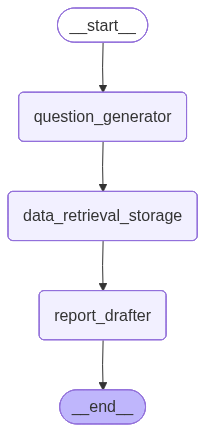

In [79]:
try:
    display(Image(competitive_analysis.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    print(f"[VISUALIZATION] Could not render graph image: {str(e)}")
    print(competitive_analysis.get_graph().draw_mermaid())
    pass

# **Execution**

Invoking the workflow with the company  name as input.

In [80]:
# Provide a company name and execute the workflow here
companyname = 'Tesla'
result =competitive_analysis.invoke(
    CompetitiveAnalysisState(
        company_name = companyname,
        vectorstore=vector_store
        )
    )

[NODE]: run_question_generator
--VALIDATING COMPANY NAME FROM WEBSEARCH--
Name: Tesla is a valid company! 

--VALIDATING COMPANY NAME FROM LLM--
Is Tesla a valid company? True 

---RETRIEVING TESLA INDUSTRY--
Sector: Automotive / Energy 

----GETTING LIST OF QUESTIONS--
Question 1: Who are Tesla's main competitors in the electric vehicle market?
Question 2: How does Tesla's pricing strategy compare to its competitors?
Question 3: What technological advancements does Tesla have over its competitors?
Question 4: How does Tesla's supply chain management differ from traditional automotive companies?
Question 5: What are Tesla's key strengths in the electric vehicle industry?
Question 6: What weaknesses does Tesla face in the current market?
Question 7: What market opportunities exist for Tesla in emerging markets?
Question 8: How does Tesla's brand perception compare to that of its competitors?
Question 9: What are the key features that differentiate Tesla vehicles from other electric vehi

For better readability, displaying the report in Markdown format

In [81]:
display(Markdown(result['report']))

# Competitive Analysis Report for Tesla in the Automotive / Energy Sector

## 1. Executive Summary
Tesla, a leader in the electric vehicle (EV) and energy sectors, faces a dynamic competitive landscape characterized by both traditional automakers and emerging players. This report analyzes Tesla's market position relative to competitors such as Ford, General Motors, BYD, Volkswagen, and NIO. Key dimensions of comparison include market share, product offerings, pricing strategies, technology, supply chain, and customer sentiment. The analysis identifies Tesla's unique strengths, potential threats, and actionable strategies to enhance its market position.

## 2. Industry Overview
The automotive and energy sectors are undergoing significant transformation driven by technological advancements, regulatory changes, and shifting consumer preferences towards sustainability. The demand for electric vehicles is rising globally, with governments promoting eco-friendly technologies. However, competition is intensifying, particularly from established manufacturers pivoting to EVs and new entrants from China.

## 3. Competitor Landscape
Tesla's primary competitors include:
- **Ford**: A legacy automaker transitioning to electric vehicles with significant investments in EV technology.
- **General Motors**: Focused on electrification and sustainability, GM is ramping up its EV offerings.
- **BYD Company Ltd**: A leading Chinese EV manufacturer with a strong domestic market presence and expanding international reach.
- **Volkswagen**: A traditional carmaker aggressively investing in EV technology and infrastructure.
- **NIO Inc.**: An emerging Chinese EV manufacturer known for its innovative battery-swapping technology.

## 4. Dimension-by-Dimension Comparison

### Market Share
Tesla has experienced fluctuations in market share, particularly in the U.S. and Europe, where it faces increasing competition from BYD and Volkswagen. Despite its strong brand presence, Tesla's market share is declining due to aggressive competition and changing consumer preferences.

### Products & Services
Tesla's product portfolio includes electric vehicles, energy storage solutions, and solar products. Its key differentiators are its innovative battery technology (e.g., 4680 cell), extensive Supercharger network, and advanced software capabilities. Competitors like Ford and GM are expanding their EV lineups but lack the same level of integrated technology.

### Pricing Strategies
Tesla employs a flexible pricing model that adjusts based on demand and supply, contrasting with competitors who often rely on discounts. This strategy allows Tesla to maintain competitive pricing while managing costs effectively. However, frequent price changes may undermine consumer trust.

### Technology
Tesla invests significantly more in R&D compared to its competitors, focusing on advanced battery technology, autonomous driving, and software integration. This investment provides Tesla with a sustained competitive advantage in innovation and efficiency.

### Supply Chain
Tesla's supply chain is vulnerable to geopolitical factors, particularly its reliance on Chinese materials. Trade tensions and tariffs can disrupt operations, affecting production costs. Competitors with more diversified supply chains may have an advantage in operational efficiency.

### Customer Sentiment
Tesla enjoys strong brand loyalty and positive customer sentiment due to its innovative products and commitment to sustainability. However, recent leadership changes and anti-Tesla sentiment may impact brand perception and customer loyalty.

## 5. Key Differentiators
- **Innovative Technology**: Tesla's superior battery technology and in-house manufacturing capabilities set it apart from competitors.
- **Extensive Supercharger Network**: This infrastructure enhances the convenience of owning a Tesla vehicle.
- **Strong R&D Investment**: Tesla's commitment to research and development fosters continuous innovation.

## 6. Threats & Vulnerabilities
- **Increased Competition**: Legacy automakers and new entrants are intensifying competition, particularly in the EV market.
- **Supply Chain Risks**: Geopolitical factors and reliance on specific materials pose risks to production and costs.
- **Market Share Decline**: Tesla is losing market share to competitors like BYD and Volkswagen, particularly in key markets.

## 7. Actionable Recommendations
1. **Enhance Brand Loyalty**: Implement strategies to build long-term customer relationships, such as loyalty programs and improved customer service.
2. **Diversify Supply Chain**: Explore alternative sourcing options to mitigate risks associated with geopolitical factors and material shortages.
3. **Strengthen Market Position**: Focus on expanding production capabilities in key markets and adapting products to regional preferences.
4. **Maintain Competitive Pricing**: While flexible pricing is beneficial, establish a more stable pricing strategy to enhance consumer trust and loyalty.

## 8. Conclusion
Tesla remains a formidable player in the automotive and energy sectors, driven by its innovative technology and strong brand presence. However, the company must navigate increasing competition and potential vulnerabilities in its supply chain. By focusing on enhancing customer loyalty, diversifying its supply chain, and maintaining a competitive pricing strategy, Tesla can strengthen its market position and continue to lead in the EV revolution.